# Basic EDA 



In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_loader import load_products, load_events, resolve_item_ids

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)

DATA_DIR = Path('data')
PRODUCTS_PATH = DATA_DIR / 'products.csv'
EVENTS_PATH = DATA_DIR / 'events.csv'


### Dataset shape and schema

In [3]:
products = load_products(PRODUCTS_PATH)
events_raw = load_events(EVENTS_PATH)
events = resolve_item_ids(events_raw, products)

print('products shape:', products.shape)
print('events_raw shape:', events_raw.shape)
print('events_resolved shape:', events.shape)

display(products.head())
display(events.head())


[Products] 1,393 unique products | 53 categories
[Events] 3,431,074 rows | 47,363 users
[Events] Event types:
event_name
view_item      2748237
add_to_cart     667282
purchase         15555
[Events] Items resolved to catalog: 3,431,074/3,431,074
products shape: (1393, 11)
events_raw shape: (3431074, 18)
events_resolved shape: (3431074, 18)


,product_id,title,category,category2,category3,brand,variant,price,description,tags,appearance_count
0,GGOEGXXX1109,Google Zip Hoodie F/C,Home/Apparel/Men's / Unisex/,(not set),(not set),(not set),(not set),60.0,Google Zip Hoodie F/C. Home/Apparel/Men's / Unisex/. Price: $60,Home/Apparel/Men's / Unisex/,29393
1,GGOEGXXX0913,Google Crewneck Sweatshirt Navy,Home/Apparel/Men's / Unisex/,(not set),(not set),(not set),(not set),55.0,Google Crewneck Sweatshirt Navy. Home/Apparel/Men's / Unisex/. Price: $55,Home/Apparel/Men's / Unisex/,26705
2,GGOEGXXX1344,Google Navy Speckled Tee,Home/Apparel/Men's / Unisex/,(not set),(not set),(not set),(not set),30.0,Google Navy Speckled Tee. Home/Apparel/Men's / Unisex/. Price: $30,Home/Apparel/Men's / Unisex/,26396
3,GGOEGXXX0905,Google Tee Yellow,Home/Sale/,(not set),(not set),(not set),(not set),22.0,Google Tee Yellow. Home/Sale/. Price: $22,Home/Sale/,24216
4,GGOEAFKA087599,Android Large Removable Sticker Sheet,Home/Sale/,(not set),(not set),(not set),(not set),3.0,Android Large Removable Sticker Sheet. Home/Sale/. Price: $3,Home/Sale/,23579


,user_id,session_id,event_name,event_date,event_timestamp,item_id,item_name,item_category,item_category2,item_brand,item_variant,price,quantity,device_category,country,page_title,engagement_time_msec,timestamp
0,1000631.1195930056,1000631.1195930056_2538888316,view_item,20201106,2020-11-06 14:59:11.446757 UTC,GGOEAHPJ131210,Android Iconic Beanie,Home/Apparel/Hats/,(not set),(not set),(not set),10,1,mobile,(not set),Hats | Apparel | Google Merchandise Store,3725.0,2020-11-06 14:59:11.446757+00:00
1,1000631.1195930056,1000631.1195930056_2538888316,view_item,20201106,2020-11-06 14:59:11.446757 UTC,GGOEGHPJ107510,Google Tracking Hat,Home/Apparel/Hats/,(not set),(not set),(not set),32,1,mobile,(not set),Hats | Apparel | Google Merchandise Store,3725.0,2020-11-06 14:59:11.446757+00:00
2,1000631.1195930056,1000631.1195930056_2538888316,view_item,20201106,2020-11-06 14:59:11.446757 UTC,GGOEGAEC134910,Google Speckled Beanie Navy,Home/Apparel/Hats/,(not set),(not set),(not set),20,1,mobile,(not set),Hats | Apparel | Google Merchandise Store,3725.0,2020-11-06 14:59:11.446757+00:00
3,1000631.1195930056,1000631.1195930056_2538888316,view_item,20201106,2020-11-06 14:59:11.446757 UTC,GGOEYHBB102199,YouTube Twill Sandwich Cap Black,Home/Apparel/Hats/,(not set),YouTube,(not set),13,1,mobile,(not set),Hats | Apparel | Google Merchandise Store,3725.0,2020-11-06 14:59:11.446757+00:00
4,1000631.1195930056,1000631.1195930056_2538888316,view_item,20201106,2020-11-06 14:59:11.446757 UTC,GGOEGAED134810,Google Heathered Pom Beanie,Home/Apparel/Hats/,(not set),(not set),(not set),15,1,mobile,(not set),Hats | Apparel | Google Merchandise Store,3725.0,2020-11-06 14:59:11.446757+00:00


### Cold-start users and Warm-start users

In [6]:
from data_loader import load_products, load_events, resolve_item_ids, apply_weights_and_decay, split_data
import pandas as pd

# 1. Define your paths (Update these if your CSVs are located elsewhere)
PRODUCTS_PATH = "/home/pranshu/Downloads/lightfm_trial/products.csv"
EVENTS_PATH   = "/home/pranshu/Downloads/lightfm_trial/events.csv"

# 2. Run the data loading pipeline
products = load_products(PRODUCTS_PATH)
events   = load_events(EVENTS_PATH)
events   = resolve_item_ids(events, products)
events   = apply_weights_and_decay(events)

# =====================================================================
# OPTIONAL: 5-CORE FILTER (Remove 1-time visitors)
# Uncomment the 3 lines below to see how it changes your Warm/Cold count!
# =====================================================================
user_counts = events['user_id'].value_counts()
valid_users = user_counts[user_counts >= 5].index
events = events[events['user_id'].isin(valid_users)].copy()
# =====================================================================

# 3. Now perform the split!
train_df, test_df = split_data(events)

# 4. Calculate Warm vs Cold start users using Pandas
known_users = train_df['user_id'].unique()
test_unique_users = pd.Series(test_df['user_id'].unique())

warm_start_users = test_unique_users.isin(known_users).sum()
cold_start_users = (~test_unique_users.isin(known_users)).sum()

print("\n" + "="*40)
print(f"Total Unique Users in Test: {len(test_unique_users):,}")
print(f"Warm-Start Users: {warm_start_users:,}")
print(f"Cold-Start Users: {cold_start_users:,}")
print("="*40)

[Products] 1,393 unique products | 53 categories
[Events] 3,431,074 rows | 47,363 users
[Events] Event types:
event_name
view_item      2748237
add_to_cart     667282
purchase         15555
[Events] Items resolved to catalog: 3,431,074/3,431,074
[Split] Cutoff: 2021-01-08 15:40:06.560111104+00:00
[Split] Train: 2,742,768 | Test: 685,370
[Split] Sessions — train: 46249 | test: 12430 | dropped (straddling): 2
[Split] Cold-start events in test: 592,196

Total Unique Users in Test: 10,288
Warm-Start Users: 937
Cold-Start Users: 9,351


### Missing values and duplicates

In [4]:
product_summary = pd.DataFrame({
    'column': products.columns,
    'dtype': products.dtypes.astype(str).values,
    'missing_pct': (products.isna().mean() * 100).round(2).values,
    'n_unique': [products[col].nunique(dropna=True) for col in products.columns],
})

event_summary = pd.DataFrame({
    'column': events.columns,
    'dtype': events.dtypes.astype(str).values,
    'missing_pct': (events.isna().mean() * 100).round(2).values,
    'n_unique': [events[col].nunique(dropna=True) for col in events.columns],
})

print('Duplicate product_id rows:', int(products.duplicated('product_id').sum()))
print('Duplicate event rows:', int(events.duplicated().sum()))

display(product_summary)
display(event_summary)


Duplicate product_id rows: 0
Duplicate event rows: 46


,column,dtype,missing_pct,n_unique
0,product_id,object,0.0,1393
1,title,object,0.0,429
2,category,object,0.0,53
3,category2,object,0.0,1
4,category3,object,0.0,1
5,brand,object,0.0,7
6,variant,object,0.0,30
7,price,float64,0.0,72
8,description,object,0.0,1390
9,tags,object,0.0,253


,column,dtype,missing_pct,n_unique
0,user_id,object,0.00,47363
1,session_id,object,0.00,60112
2,event_name,object,0.00,3
3,event_date,int64,0.00,92
4,event_timestamp,object,0.00,280560
5,item_id,object,0.00,821
6,item_name,object,0.00,429
7,item_category,object,0.31,80
8,item_category2,object,0.00,1
9,item_brand,object,0.04,6


### Catalog coverage

In [5]:
catalog_item_ids = set(products['product_id'])

catalog_overview = pd.DataFrame({
    'metric': [
        'unique_products',
        'unique_categories',
        'unique_brands',
        'price_min',
        'price_median',
        'price_mean',
        'price_max',
    ],
    'value': [
        products['product_id'].nunique(),
        products['category'].nunique(),
        products['brand'].nunique(),
        round(products['price'].min(), 2),
        round(products['price'].median(), 2),
        round(products['price'].mean(), 2),
        round(products['price'].max(), 2),
    ],
})

top_categories = products['category'].value_counts().head(10).rename_axis('category').reset_index(name='count')
top_brands = products['brand'].replace('', 'unknown').value_counts().head(10).rename_axis('brand').reset_index(name='count')

display(catalog_overview)
display(top_categories)
display(top_brands)


,metric,value
0,unique_products,1393.0
1,unique_categories,53.0
2,unique_brands,7.0
3,price_min,0.0
4,price_median,20.0
5,price_mean,26.4
6,price_max,313.0


,category,count
0,Apparel,372
1,Campus Collection,117
2,Home/Campus Collection/,86
3,Clearance,75
4,Home/Sale/,74
5,Home/Apparel/Men's / Unisex/,58
6,New,45
7,Home/Apparel/Kids/,42
8,Accessories,39
9,Uncategorized Items,35


,brand,count
0,Google,814
1,(not set),416
2,Android,82
3,YouTube,35
4,#IamRemarkable,22
5,unknown,14
6,Google Cloud,10


This section helps us understand how rich the product metadata is. If categories, brands, and prices carry enough variation, a content-based recommender has a better chance of learning meaningful item similarity.


### Event distribution

In [6]:
n_users = events['user_id'].nunique()
n_event_items = events['item_id'].nunique()
n_catalog_items = products['product_id'].nunique()
resolved_rate = events['item_id'].isin(catalog_item_ids).mean()
user_activity = events.groupby('user_id').size().sort_values(ascending=False)
item_activity = events.groupby('item_id').size().sort_values(ascending=False)
interaction_sparsity = 1 - (len(events) / (n_users * n_catalog_items))

event_overview = pd.DataFrame({
    'metric': [
        'total_events',
        'unique_users',
        'unique_event_items',
        'catalog_items',
        'timestamp_min',
        'timestamp_max',
        'catalog_resolution_rate',
        'avg_events_per_user',
        'median_events_per_user',
        'avg_events_per_item',
        'median_events_per_item',
        'interaction_matrix_sparsity',
    ],
    'value': [
        len(events),
        n_users,
        n_event_items,
        n_catalog_items,
        events['timestamp'].min(),
        events['timestamp'].max(),
        round(resolved_rate, 4),
        round(user_activity.mean(), 2),
        round(user_activity.median(), 2),
        round(item_activity.mean(), 2),
        round(item_activity.median(), 2),
        round(interaction_sparsity, 6),
    ],
})

event_type_counts = events['event_name'].value_counts().rename_axis('event_name').reset_index(name='count')

display(event_overview)
display(event_type_counts)
display(user_activity.describe().rename('user_activity'))
display(item_activity.describe().rename('item_activity'))


,metric,value
0,total_events,3431074
1,unique_users,47363
2,unique_event_items,821
3,catalog_items,1393
4,timestamp_min,2020-11-01 00:07:50.895046+00:00
5,timestamp_max,2021-01-31 23:59:08.568489+00:00
6,catalog_resolution_rate,1.0
7,avg_events_per_user,72.44
8,median_events_per_user,24.0
9,avg_events_per_item,4179.14


,event_name,count
0,view_item,2748237
1,add_to_cart,667282
2,purchase,15555


count    47363.000000
mean        72.442075
std        140.719437
min          1.000000
25%         12.000000
50%         24.000000
75%         60.000000
max       3256.000000
Name: user_activity, dtype: float64

count      821.000000
mean      4179.140073
std       9061.811030
min          1.000000
25%         55.000000
50%        280.000000
75%       3706.000000
max      69921.000000
Name: item_activity, dtype: float64

Event logs are the core recommendation signal here. A heavy dominance of `view_item` over `purchase` is expected and is one reason this is treated as an implicit-feedback recommendation problem rather than an explicit-rating problem.


### User/item interaction frequency

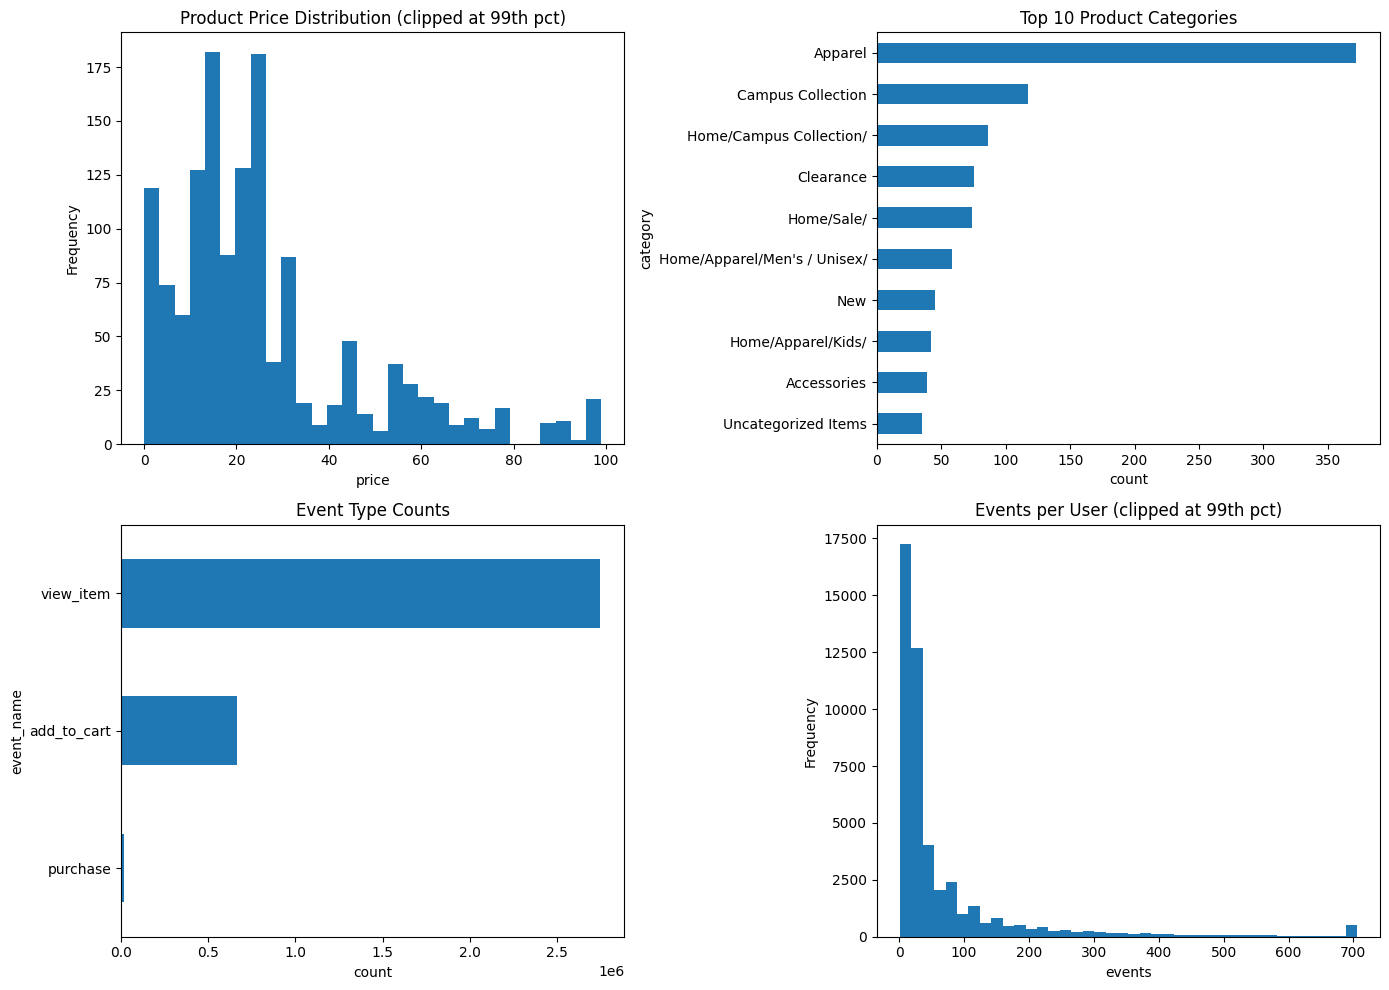

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

products['price'].clip(upper=products['price'].quantile(0.99)).plot(
    kind='hist', bins=30, ax=axes[0, 0], title='Product Price Distribution (clipped at 99th pct)'
)
axes[0, 0].set_xlabel('price')

products['category'].value_counts().head(10).sort_values().plot(
    kind='barh', ax=axes[0, 1], title='Top 10 Product Categories'
)
axes[0, 1].set_xlabel('count')

events['event_name'].value_counts().sort_values().plot(
    kind='barh', ax=axes[1, 0], title='Event Type Counts'
)
axes[1, 0].set_xlabel('count')

user_activity.clip(upper=user_activity.quantile(0.99)).plot(
    kind='hist', bins=40, ax=axes[1, 1], title='Events per User (clipped at 99th pct)'
)
axes[1, 1].set_xlabel('events')

plt.tight_layout()
plt.show()


We want to see whether user activity is concentrated in a subset of users and whether some event types dominate the dataset. That tells us how skewed the interaction data is before modeling.


### Sparsity and long-tail behavior

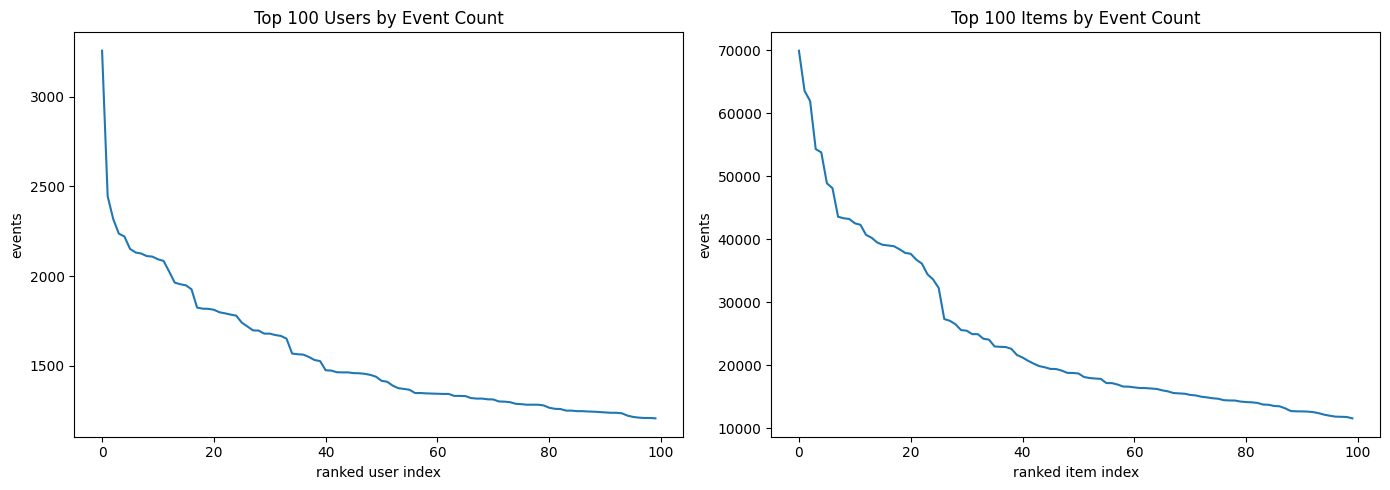

Share of events from top 10% most active users: 0.5456
Share of events from top 10% most active items: 0.6391


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

user_activity.head(100).reset_index(drop=True).plot(
    ax=axes[0], title='Top 100 Users by Event Count'
)
axes[0].set_xlabel('ranked user index')
axes[0].set_ylabel('events')

item_activity.head(100).reset_index(drop=True).plot(
    ax=axes[1], title='Top 100 Items by Event Count'
)
axes[1].set_xlabel('ranked item index')
axes[1].set_ylabel('events')

plt.tight_layout()
plt.show()

print('Share of events from top 10% most active users:', round(user_activity.head(max(1, int(len(user_activity) * 0.10))).sum() / len(events), 4))
print('Share of events from top 10% most active items:', round(item_activity.head(max(1, int(len(item_activity) * 0.10))).sum() / len(events), 4))


Recommendation data usually has a long-tail structure, where a small number of users or items account for a large fraction of all events. If that pattern is strong here, it also explains why a popularity baseline can already perform reasonably well.


[Products] 1,393 unique products | 53 categories
[Events] 3,431,074 rows | 47,363 users
[Events] Event types:
event_name
view_item      2748237
add_to_cart     667282
purchase         15555
[Events] Items resolved to catalog: 3,431,074/3,431,074
[Split] Cutoff: 2021-01-08 15:45:50.248207104+00:00
[Split] Train: 2,744,663 | Test: 685,952
[Split] Sessions — train: 47376 | test: 12850 | dropped (straddling): 3
[Split] Cold-start events in test: 592,888

Total Unique Users in Test: 10,702
Warm-Start Users: 936
Cold-Start Users: 9,766
